In [1]:
import numpy as np

# until ~2450 rocket isn't in main phase so it's useless noise
xr = np.genfromtxt('FT1_primary.csv', delimiter=',')[2450:,4]
yr = np.genfromtxt('FT1_primary.csv', delimiter=',')[2450:,19]

avg. time:  6.37348912949001e-05


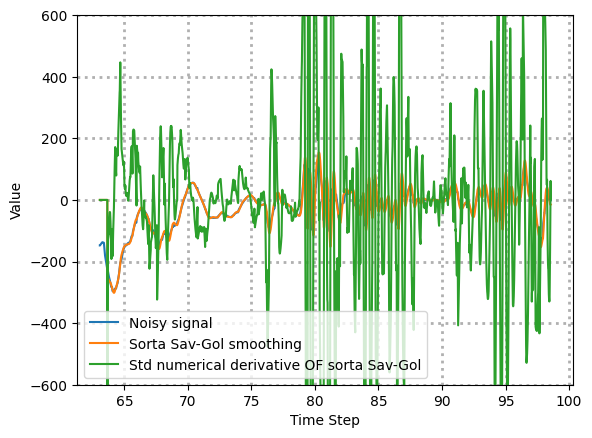

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
warnings.simplefilter('ignore', np.exceptions.RankWarning)

xres = 0.01

# interpolates (x,y) at xres (100hz)
x = np.arange(xr[0],xr[-1],xres)
y = np.interp(x,xr,yr)

totalTime = 0

# this because i'm not a good programmer
dy = 0 * y
fy = 0 * y
nfy = 0 * y
ny = 0 * y
bfy = 0 * y

# sorta Sav-Gol
winSize = 60
for i in range(winSize,len(y)):
    start_time = time.perf_counter()
    ywin = y[i-winSize:i] - [0]*winSize
    xwin = x[i-winSize:i] - [x[i]]*winSize
    py = np.polyfit(xwin,ywin,2)
    dy[i] = py[1]
    fy[i] = py[2]
    # std numerical derivative OF sorta Sav-Gol
    nfy[i] = (fy[i]-fy[i-1])/xres
    totalTime += time.perf_counter() - start_time

for i in range(winSize,len(y)-winSize):
    ywin = y[i-winSize:i+winSize] - [0]*(2*winSize)
    xwin = x[i-winSize:i+winSize] - [x[i]]*(2*winSize)
    py = np.polyfit(xwin,ywin,2)
    bfy[i] = py[2]

print("avg. time: ",totalTime / len(y))

plt.ylim(-600,600)

plt.plot(x, y, label='Noisy signal')
plt.plot(x, fy, label='Sorta Sav-Gol smoothing')
#plt.plot(x, bfy, label='Full Sav-Gol smoothing')
#plt.plot(x, dy, label='Sorta Sav-Gol derivative')
plt.plot(x, nfy, label='Std numerical derivative OF sorta Sav-Gol')
#plt.plot(x, ny, label='Std numerical derivative')
plt.grid(lw=2,ls=':')
plt.xlabel('Time Step')
plt.ylabel("Value")
plt.legend()
plt.show()


avg. time:  6.690483322180115e-05


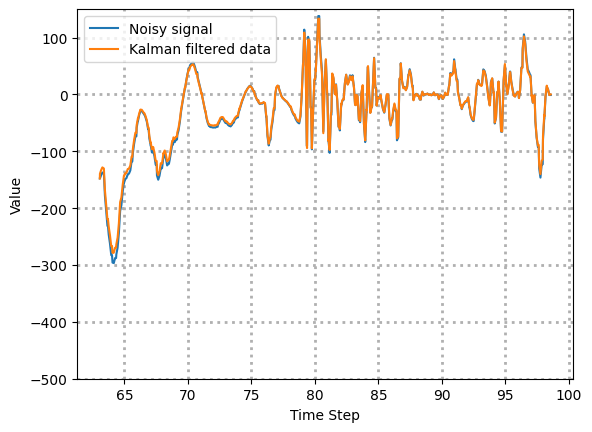

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

ys = 0 * yr
dy = 0 * yr
ny = 0 * yr
totalTime = 0

class KalmanSys:
    def __init__(self, A, H, Q, R, x, P):
        self.A = A
        self.H = H
        self.Q = Q
        self.R = R
        self.K = 0
        self.x = x0
        self.P = P0

    def update(self):
        self.x = np.dot(self.A, self.x) # predict next step
        self.P = np.dot(self.A, np.dot(self.P, np.transpose(self.A))) + self.Q #predict uncertainty in next step
        self.K = np.dot(np.dot(self.P,np.transpose(self.H)), np.linalg.inv(np.dot(self.H,np.dot(self.P, np.transpose(H))) + self.R))
        self.P = self.P - np.dot(self.K, np.dot(self.H, self.P))

    def estimate(self, z): # z is the measurement
        self.x = self.x + np.dot(self.K, (z - np.dot(self.H, self.x)))
        return self.x
        
dt = 1

# state transition matrix
A = np.array([[1, dt, 0.5*dt**2],
              [0, 1, dt],
              [0, 0, 1]])
# state measurement matrix
H = np.array([[1, 0, 0],
              [0, 1, 0]],)
# state transition noise
Q = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]])
# state measurement noise
R = np.array([[0.2, 0],
              [0, 0.2]])
# initial state
x0 = np.array([0, yr[0],0])

# initial covariance matrix
P0 = np.array([[0.1, 0, 0],
               [0, 0.1, 0],
               [0, 0, 10]])

KS = KalmanSys(A, H, Q, R, x0, P0)

for i in range(0,len(yr)-1):
    start_time = time.perf_counter()
    dt = xr[i + 1] - xr[i]
    A = np.array([[1, dt, 0.5*dt**2],
                  [0, 1, dt],
                  [0, 0, 1]])
    Q = 100 * np.array([[(dt**3)/20, (dt**4)/8, (dt**3)/6],
                      [(dt**4)/8, (dt**3)/3, (dt**2)/2],
                      [(dt**3)/6, (dt**2)/2, dt]])
    KS.update()
    ys[i] = KS.estimate(yr[i])[1]
    dy[i] = KS.estimate(yr[i])[2]
    totalTime += time.perf_counter() - start_time
    
print("avg. time: ",totalTime / len(xr))

plt.ylim(-500,150)
plt.plot(xr, yr, label='Noisy signal')
plt.plot(xr, ys, label='Kalman filtered data')
#plt.plot(xr, dy, label='Kalman filtered derivative')
plt.grid(lw=2,ls=':')
plt.xlabel('Time Step')
plt.ylabel("Value")
plt.legend()
plt.show()